# Customer Segmentation using K-Means and DBSCAN

### 1. Import Libraries
In this section, we import the necessary libraries for data manipulation, visualization, preprocessing, clustering, and evaluation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

### 2. Load the Dataset
We load the `Mall_Customers.csv` dataset and inspect the first and last few rows to understand its structure.

In [2]:
dataset = "../../Datasets/Mall_Customers.csv"

df = pd.read_csv(dataset)

df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


### 3. Check Data Types and Non-Null Counts
We use `info()` to verify features, data types, and check if there are any missing values in the columns.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 8.9 KB


### 4. Statistical Summary
We generate descriptive statistics to understand the mean, standard deviation, minimum, maximum, and quartile ranges of each feature.

In [4]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


### 5. Check for Missing (NaN) Values
We verify whether there are any null or missing values in the dataset to decide if any imputation is required.

In [5]:
print(df.isnull().sum())
print()
print(df.isna().sum())

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


### 6. Check for Duplicate Entries
We ensure there are no duplicate rows in our dataset to maintain data integrity and prevent double-counting.

In [6]:
print(df.duplicated().sum())

0


### 7. Exploratory Data Analysis (EDA)
We visualize the distributions of individual features (Histograms), bivariate relationships between income and spending score, and general feature correlation (Pairplot) to detect patterns and natural groupings.

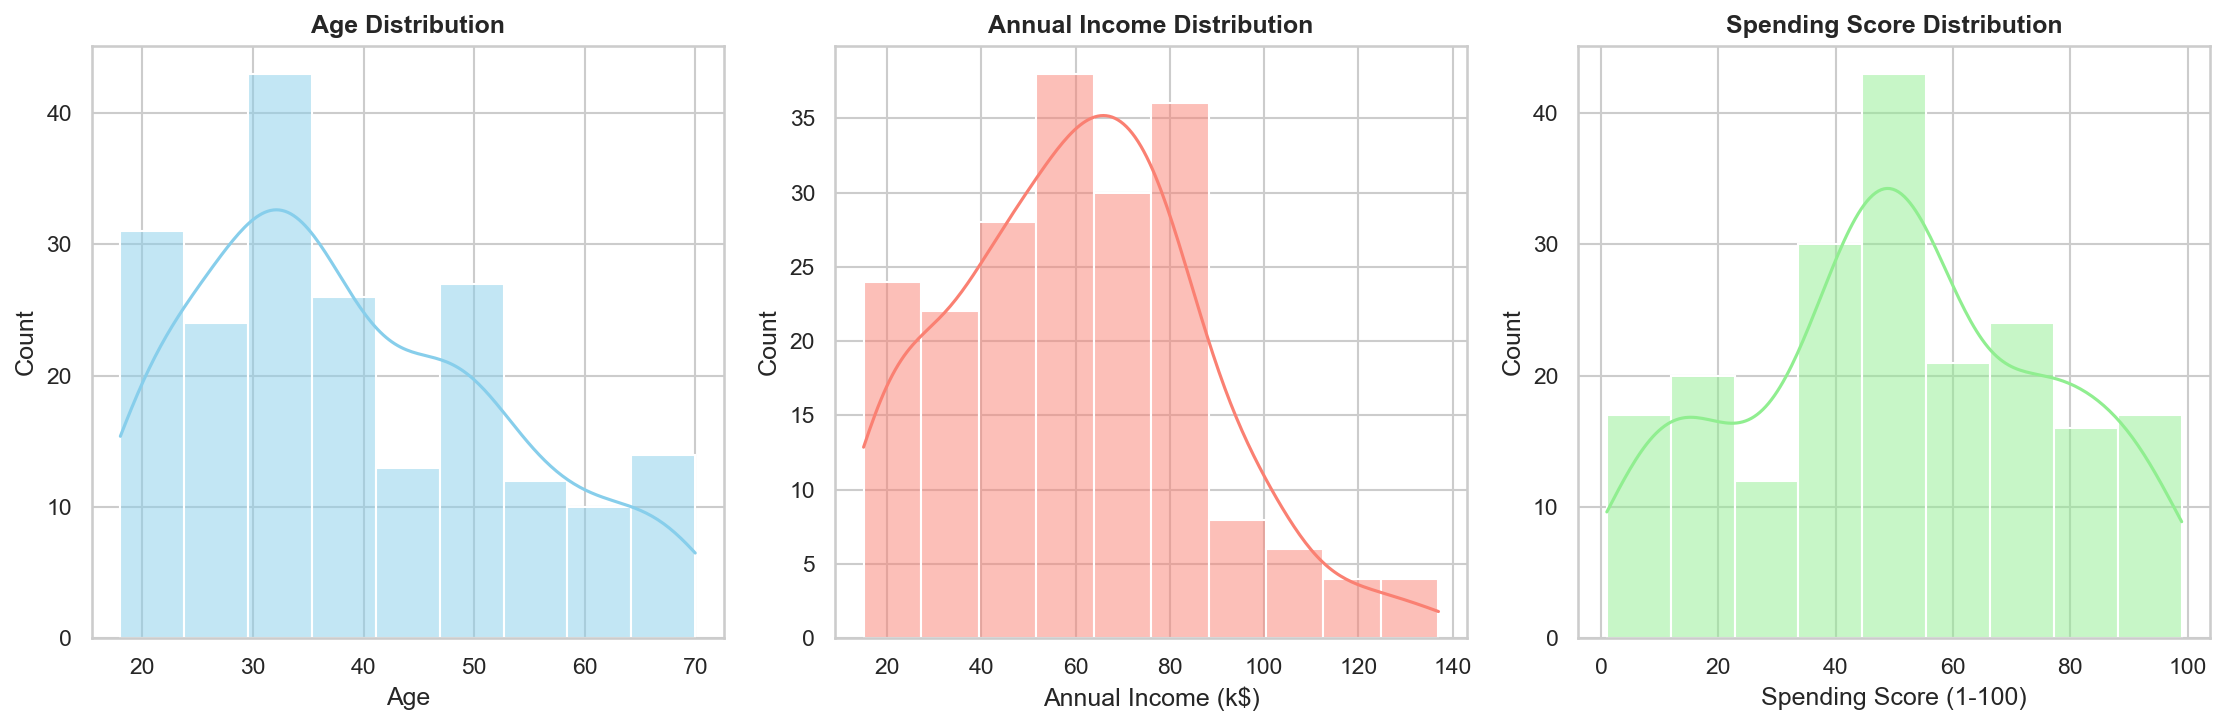

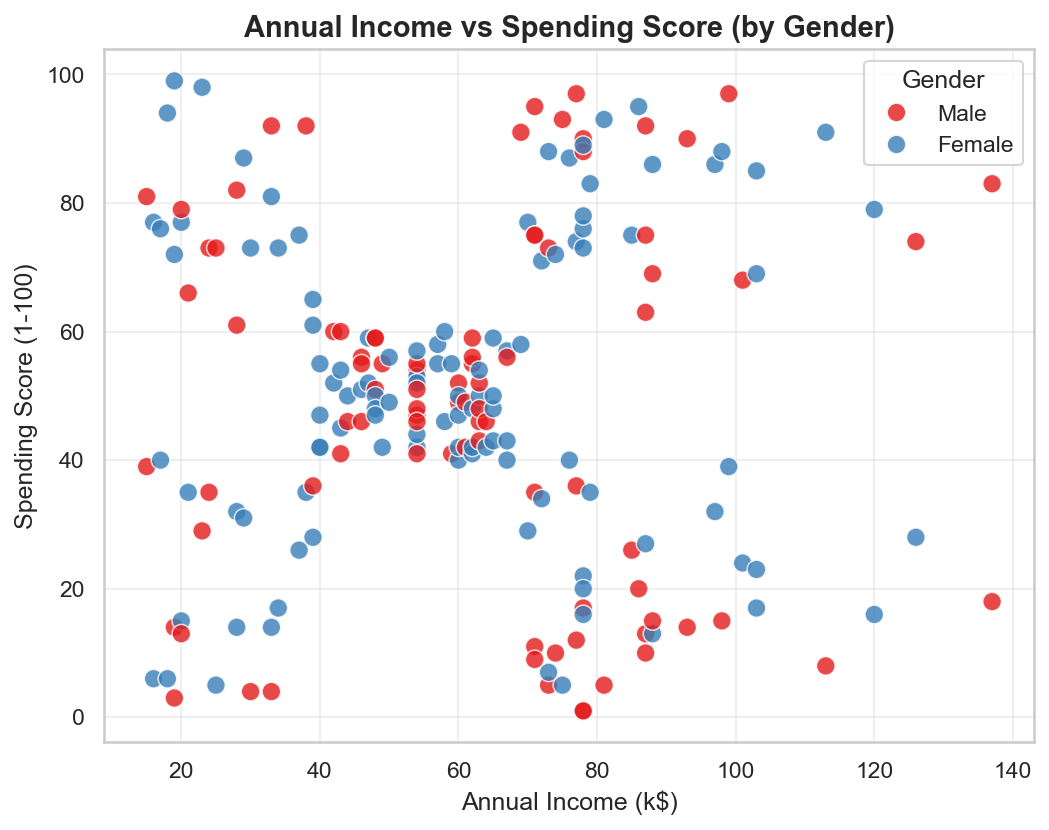

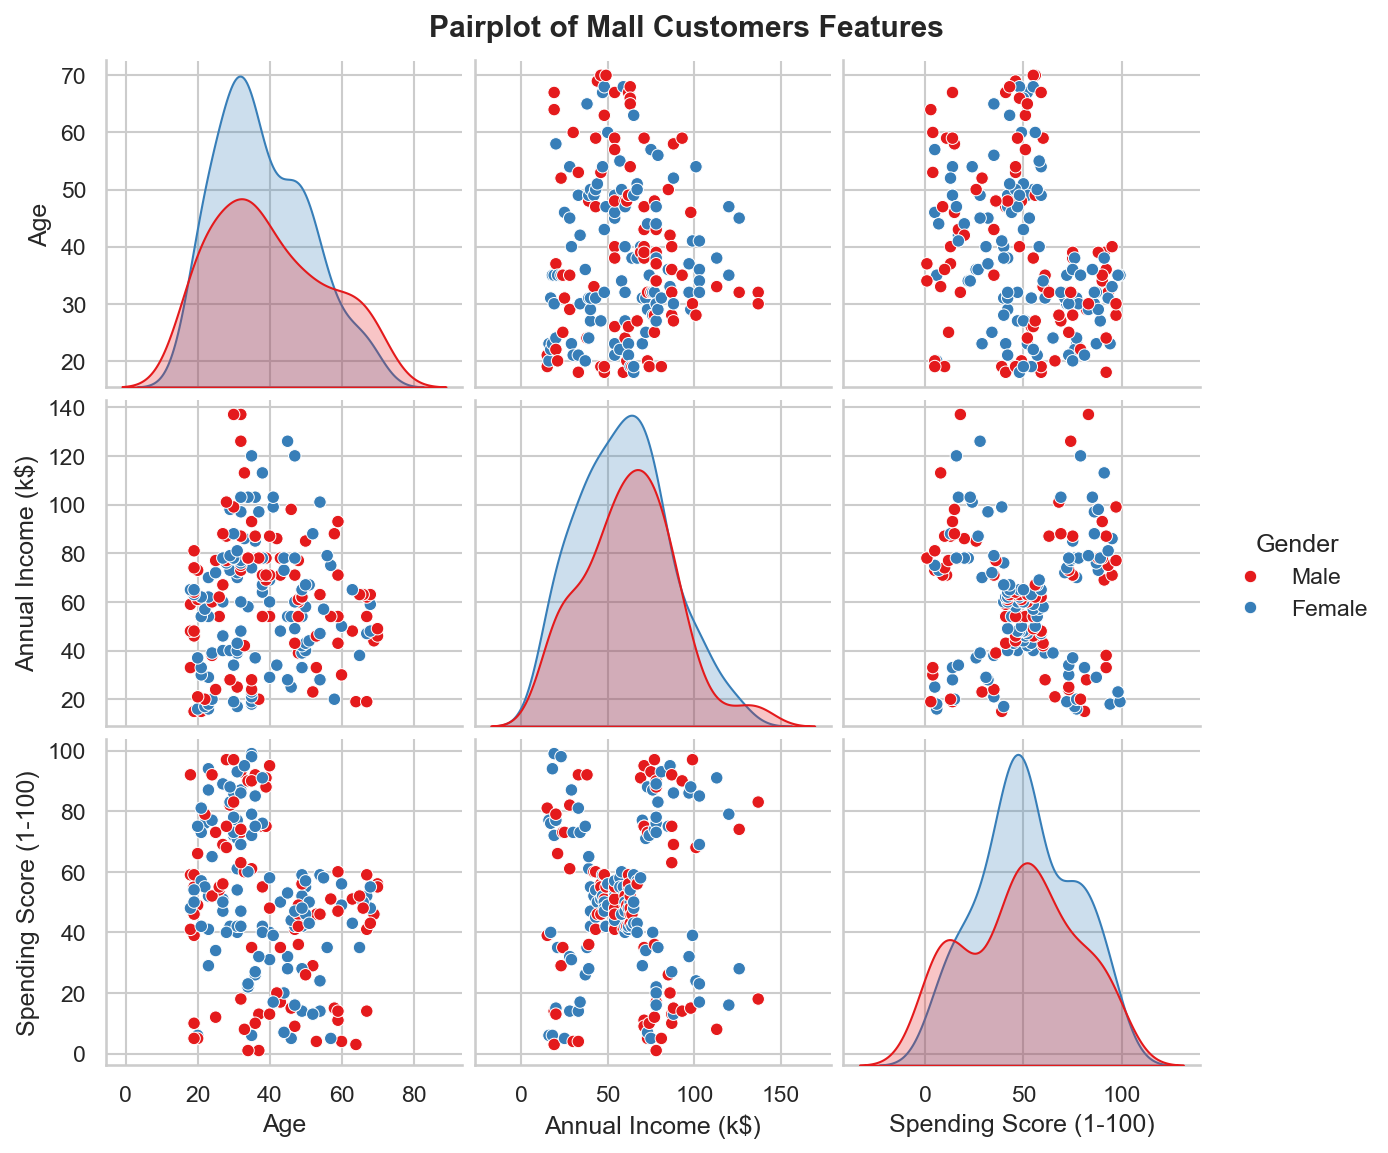

In [7]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 150

# -------------------------------------------------------------
# PLOT 1: Histograms (Age, Income, Spending Score Distributions)
# -------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
# Age distribution
sns.histplot(df['Age'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Age Distribution', fontsize=12, fontweight='bold')
# Income distribution
sns.histplot(df['Annual Income (k$)'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Annual Income Distribution', fontsize=12, fontweight='bold')
# Spending Score distribution
sns.histplot(df['Spending Score (1-100)'], kde=True, ax=axes[2], color='lightgreen')
axes[2].set_title('Spending Score Distribution', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# -------------------------------------------------------------
# PLOT 2: Scatter Plot (Annual Income vs Spending Score by Gender)
# -------------------------------------------------------------
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df, 
    x='Annual Income (k$)', 
    y='Spending Score (1-100)', 
    hue='Gender', 
    palette='Set1', 
    s=80, 
    alpha=0.8, 
    edgecolor='w'
)
plt.title('Annual Income vs Spending Score (by Gender)', fontsize=14, fontweight='bold')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Gender')
plt.grid(True, alpha=0.3)
plt.show()

# -------------------------------------------------------------
# PLOT 3: Pairplot (Overview of all features)
# -------------------------------------------------------------
pairplot_df = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Gender']]
g = sns.pairplot(
    pairplot_df, 
    hue='Gender', 
    palette='Set1', 
    height=2.5, 
    aspect=1.1, 
    diag_kind='kde'
)
g.fig.suptitle('Pairplot of Mall Customers Features', y=1.02, fontweight='bold')
plt.show()


### 8. Feature Selection
We extract our clustering features: `Age`, `Annual Income (k$)`, and `Spending Score (1-100)` into a NumPy array `X`.

In [8]:
X = df[["Age", "Annual Income (k$)", 'Spending Score (1-100)']].values

### 9. Feature Standardization
We apply `StandardScaler` to normalize our features so that features with larger ranges (like income) do not dominate the distance calculations in our clustering algorithms.

In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### 10. K-Means Clustering
We fit the K-Means algorithm using $K=6$ clusters on our scaled dataset and assign cluster labels to each customer.

In [15]:
kmeans = KMeans(n_clusters=6, random_state=42)
df['Cluster_3d'] = kmeans.fit_predict(X_scaled)

### 11. 3D Visualization of K-Means Clusters
We plot our K-Means clusters in a 3D scatter plot along the `Age`, `Annual Income`, and `Spending Score` axes to visualize the customer segments.

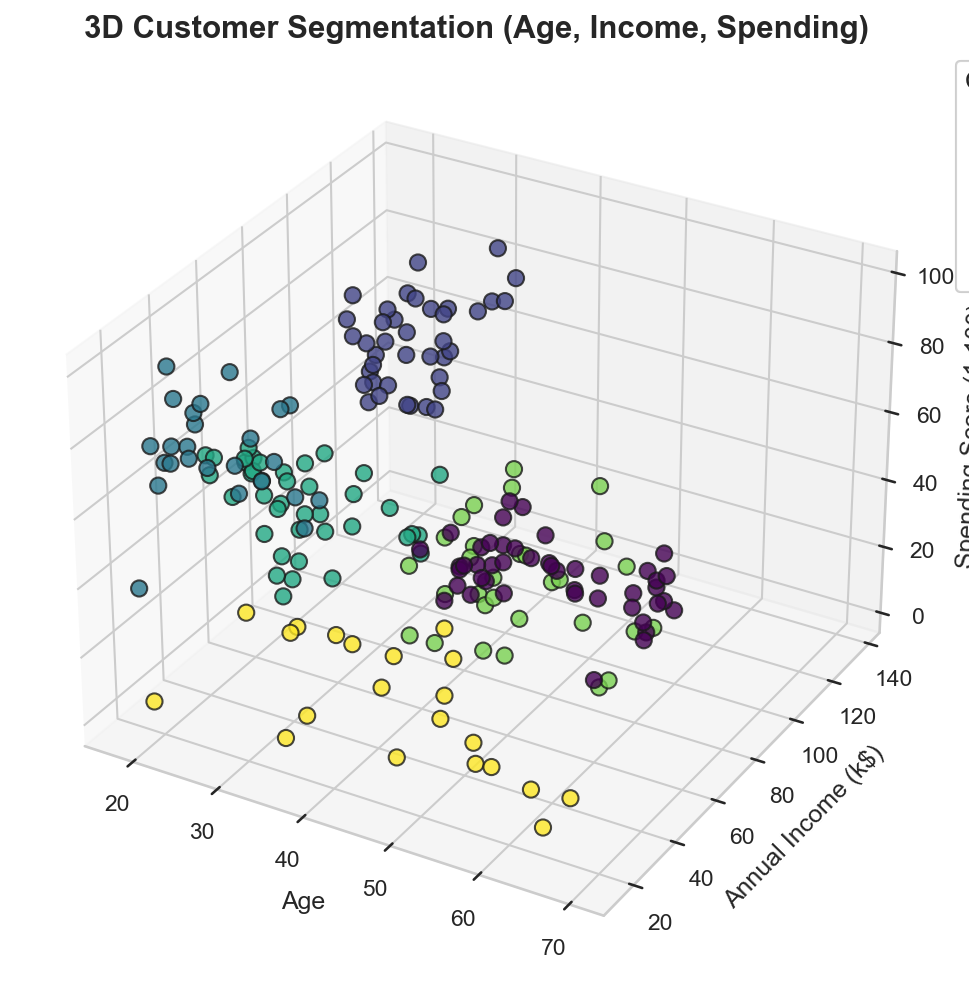

In [16]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    df['Age'], 
    df['Annual Income (k$)'], 
    df['Spending Score (1-100)'], 
    c=df['Cluster_3d'], 
    cmap='viridis', 
    s=60, 
    edgecolor='k', 
    alpha=0.8
)

ax.set_title('3D Customer Segmentation (Age, Income, Spending)', fontsize=15, fontweight='bold')
ax.set_xlabel('Age')
ax.set_ylabel('Annual Income (k$)')
ax.set_zlabel('Spending Score (1-100)')

legend = ax.legend(*scatter.legend_elements(), title="Clusters", bbox_to_anchor=(1.15, 1))
ax.add_artist(legend)
plt.show()

### 12. Epsilon Tuning for DBSCAN
We use the K-Distance Graph (plotting the distance to the 5th nearest neighbor for each point) to identify the optimal value of `eps` (Epsilon) for DBSCAN.

In [19]:
from sklearn.neighbors import NearestNeighbors

neighbors = NearestNeighbors(n_neighbors=6)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

sorted_distances = np.sort(distances[:, 5], axis=0)

### 13. DBSCAN Clustering
We fit the DBSCAN algorithm with our optimal parameters: `eps=0.45` and `min_samples=6`, allowing the model to naturally identify dense regions and classify outliers as noise.

In [21]:
dbscan_3d = DBSCAN(eps=0.45, min_samples=6)
df['DBSCAN_Cluster_3D'] = dbscan_3d.fit_predict(X_scaled)

### 14. 3D Visualization of DBSCAN Clusters
We visualize the DBSCAN clusters (including noise points labeled as `-1`) on a 3D scatter plot to inspect the density-based customer segments.

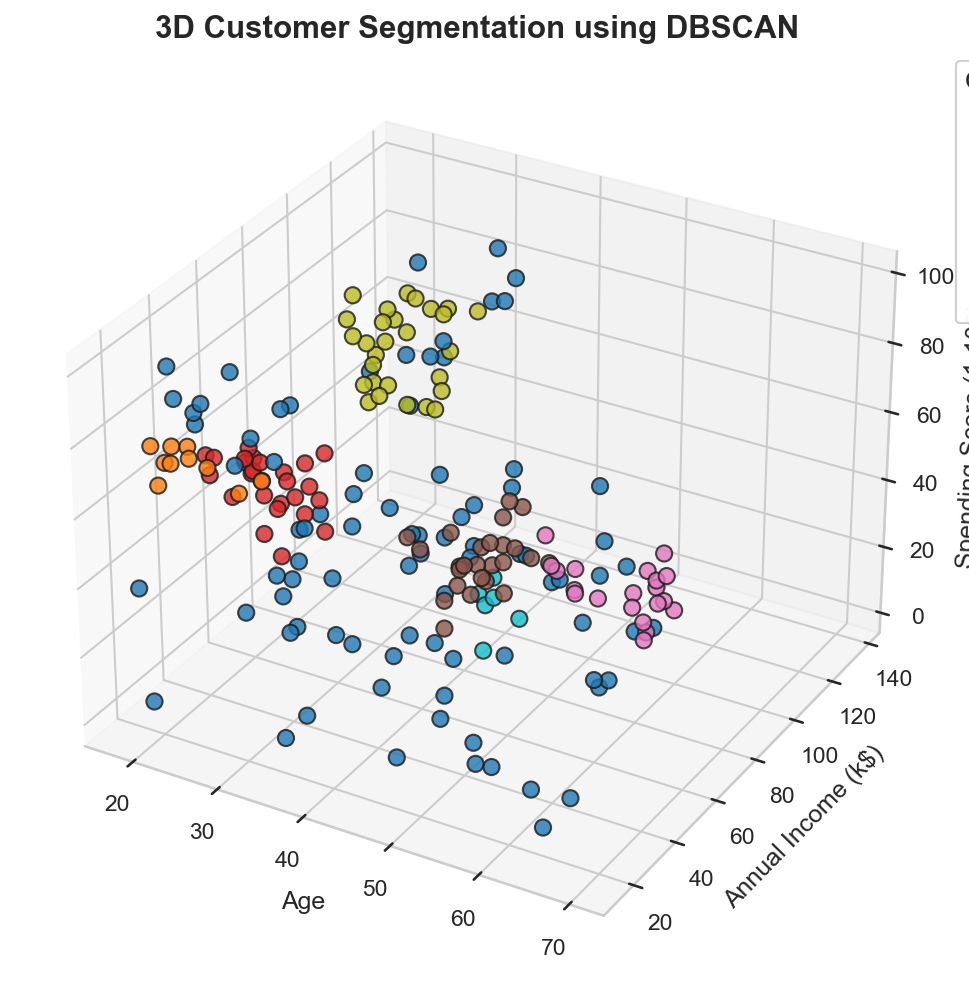

In [22]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    df['Age'], 
    df['Annual Income (k$)'], 
    df['Spending Score (1-100)'], 
    c=df['DBSCAN_Cluster_3D'], 
    cmap='tab10', 
    s=60, 
    edgecolor='k', 
    alpha=0.8
)

ax.set_title('3D Customer Segmentation using DBSCAN', fontsize=15, fontweight='bold')
ax.set_xlabel('Age')
ax.set_ylabel('Annual Income (k$)')
ax.set_zlabel('Spending Score (1-100)')

legend = ax.legend(*scatter.legend_elements(), title="Clusters", bbox_to_anchor=(1.15, 1))
ax.add_artist(legend)
plt.show()

### 15. Model Evaluation (Silhouette Scores)
We calculate and compare the Silhouette Scores for both K-Means and DBSCAN to evaluate clustering quality and choose the most suitable model.

In [25]:
kmeans_silhouette = silhouette_score(X_scaled, df['Cluster_3d'])
print(f"K-Means Silhouette Score: {kmeans_silhouette:.3f}")

dbscan_mask = df['DBSCAN_Cluster_3D'] != -1
if len(df.loc[dbscan_mask, 'DBSCAN_Cluster_3D'].unique()) > 1:
    dbscan_silhouette = silhouette_score(
        X_scaled[dbscan_mask], 
        df.loc[dbscan_mask, 'DBSCAN_Cluster_3D']
    )
    print(f"DBSCAN Silhouette Score (excluding noise): {dbscan_silhouette:.3f}")
else:
    print("DBSCAN did not find enough distinct clusters to calculate a silhouette score.")

K-Means Silhouette Score: 0.431
DBSCAN Silhouette Score (excluding noise): 0.556


# Model Comparison, Business Insights, and Conclusion

### 1. Model Comparison
| Metric | K-Means ($K=6$) | DBSCAN (`eps=0.45`, `min_samples=6`) |
| :--- | :--- | :--- |
| **Silhouette Score** | **0.431** | **0.556** (excluding noise) |
| **Outlier Handling** | Forces outliers into clusters, stretching boundaries. | Successfully identifies outliers and flags them as noise (`-1`). |
| **Cluster Shapes** | Assumes spherical, convex clusters of similar size. | Identifies arbitrary-shaped clusters based on local density. |
| **Marketing Coverage** | 100% of customers are assigned to a cluster. | Only dense customer groups are segmented; outliers are unassigned. |

### 2. Business Insights
* **VIP Shoppers (High Income, High Spend):** Customers with high income and high spending scores. They should be targeted with exclusive rewards, premium loyalty programs, and high-end product offers.
* **Careless/Impulsive Shoppers (Low Income, High Spend):** Generally younger shoppers who spend a lot despite lower incomes. Target with flash sales, trend-driven digital marketing, and entry-level fashion lines.
* **Frugal/Careful Shoppers (High Income, Low Spend):** Customers with high income but low spending scores. Target with utility-based marketing, value-driven bulk offers, and quality-assurance campaigns.
* **Sensible Shoppers (Moderate Income, Moderate Spend):** Standard middle-class buyers. Target with general newsletter campaigns, point-based loyalty systems, and brand engagement discounts.
* **Age Factor:** High spending scores are strongly correlated with younger shoppers (under 40), suggesting marketing spend should prioritize this demographic for high-end trends.

### 3. Conclusion
* **DBSCAN** mathematically outperforms K-Means (Silhouette Score `0.556` vs `0.431`) because it isolates outliers as noise rather than forcing them to distort the cluster centers. It is ideal for identifying the most distinct, high-fidelity customer groups.
* **K-Means** remains highly practical if the business goal requires 100% database coverage (where every single customer must be placed in a marketing segment), even if some boundary points are assigned less precisely.